# 06 — Score Analysis

**Goal:** Deep-dive into what the novelty scores are capturing.

**Covers:**
1. Top 20 most novel / Bottom 20 most incremental papers
2. Novelty trends over time (with NLP milestone annotations)
3. Novelty by domain (MT, QA, SA, SUM, DIA, PAR, NLI)
4. Structural vs Semantic correlation analysis
5. Summary statistics table

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Paths 
FEATURE_MATRIX = "../../outputs/final/novelty_feature_matrix_with_score.csv"
PAPER_NODES    = "../../outputs/final/paper_nodes.csv"
OUT_DIR        = "../../outputs/final/"

In [13]:
# Load and merge
fm = pd.read_csv(FEATURE_MATRIX)
pn = pd.read_csv(PAPER_NODES)[['node_id', 'split', 'domain', 'title']]
pn = pn.rename(columns={'node_id': 'paper_id'})

df = fm.merge(pn, on='paper_id', how='left')

print(f"Total papers: {len(df)}")
print(df['split'].value_counts())

Total papers: 2511
split
SKG      2099
NOVEL     412
Name: count, dtype: int64


In [14]:
# 1. Top 20 / Bottom 20 
cols = ['paper_id', 'title', 'split', 'domain', 'year',
        'composite_novelty', 'structural_novelty', 'semantic_knn', 'triple_count']

top20    = df.nlargest(20, 'composite_novelty')[cols].reset_index(drop=True)
bottom20 = df.nsmallest(20, 'composite_novelty')[cols].reset_index(drop=True)

print(" TOP 20 Most Novel Papers ")
print(top20[['paper_id', 'split', 'domain', 'year', 'composite_novelty', 'semantic_knn']].to_string())
print()
print(" BOTTOM 20 Most Incremental Papers ")
print(bottom20[['paper_id', 'split', 'domain', 'year', 'composite_novelty', 'semantic_knn']].to_string())

top20.to_csv(OUT_DIR + 'top20_novel_papers.csv', index=False)
bottom20.to_csv(OUT_DIR + 'bottom20_incremental_papers.csv', index=False)
print("\nSaved: top20_novel_papers.csv, bottom20_incremental_papers.csv")

 TOP 20 Most Novel Papers 
       paper_id split domain  year  composite_novelty  semantic_knn
0    SKG_MT_715   SKG     MT  2010           0.962938           1.0
1    SKG_QA_101   SKG     QA  2010           0.960900           1.0
2    SKG_SA_544   SKG     SA  2010           0.954057           1.0
3    SKG_MT_137   SKG     MT  2010           0.949862           1.0
4    SKG_MT_838   SKG     MT  2010           0.949617           1.0
5    SKG_MT_547   SKG     MT  2010           0.948438           1.0
6    SKG_PAR_69   SKG    PAR  2010           0.947871           1.0
7    SKG_SA_420   SKG     SA  2010           0.946312           1.0
8    SKG_MT_850   SKG     MT  2010           0.945972           1.0
9    SKG_MT_196   SKG     MT  2010           0.945621           1.0
10  SKG_MT_1074   SKG     MT  2010           0.945258           1.0
11   SKG_SA_217   SKG     SA  2010           0.944691           1.0
12   SKG_SUM_83   SKG    SUM  2010           0.944691           1.0
13  SKG_DIA_209   SKG

In [15]:
# Sanity check: what split are the top 20 from?
print("Top 20 split breakdown:")
print(top20['split'].value_counts())
print()
print("Bottom 20 split breakdown:")
print(bottom20['split'].value_counts())

Top 20 split breakdown:
split
SKG    20
Name: count, dtype: int64

Bottom 20 split breakdown:
split
SKG      19
NOVEL     1
Name: count, dtype: int64


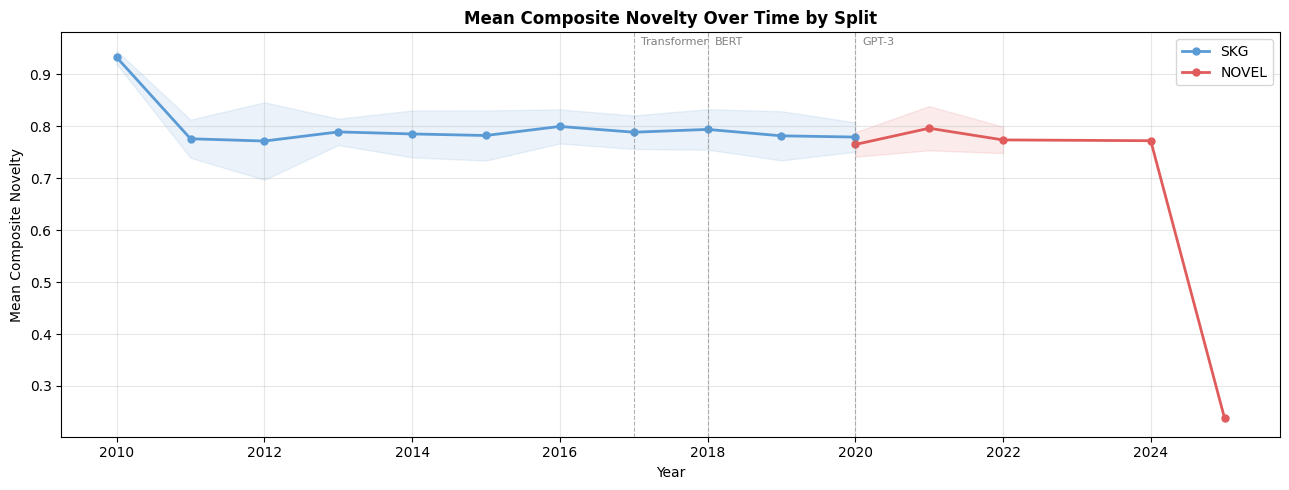

Saved: novelty_over_time.png


In [18]:
# 2. Novelty over time 
yearly = (
    df[df['year'].notna() & df['split'].notna()]
    .groupby(['year', 'split'])['composite_novelty']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
palette = {'SKG': '#5B9BD5', 'NOVEL': '#E05C5C'}

for split, color in palette.items():
    subset = yearly[yearly['split'] == split].sort_values('year')
    if len(subset) == 0:
        continue
    ax.plot(subset['year'], subset['mean'], marker='o',
            label=split, color=color, linewidth=2, markersize=5)
    ax.fill_between(subset['year'],
                    subset['mean'] - subset['std'],
                    subset['mean'] + subset['std'],
                    alpha=0.12, color=color)

# Annotate key NLP milestones
milestones = {2017: 'Transformer', 2018: 'BERT', 2020: 'GPT-3'}
for yr, label in milestones.items():
    ax.axvline(yr, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(yr + 0.1, ax.get_ylim()[1] * 0.99, label,
            fontsize=8, color='gray', va='top')

ax.set_title('Mean Composite Novelty Over Time by Split',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Composite Novelty')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../../outputs/visuals/" + 'novelty_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: novelty_over_time.png")

 Mean Composite Novelty by Domain 
split    NOVEL     SKG
domain                
DIA     0.7880  0.7869
MT      0.7854  0.7900
NLI     0.0000  0.7820
PAR     0.0000  0.7846
QA      0.8007  0.7882
SA      0.8070  0.7898
SUM     0.8088  0.7925


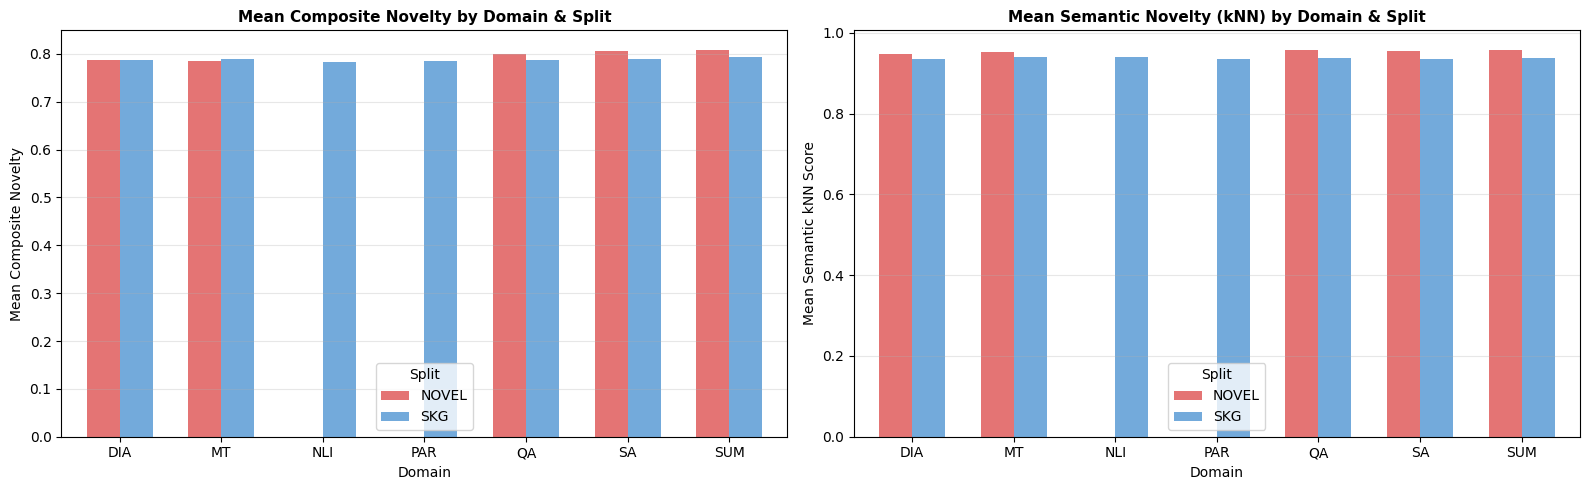

Saved: novelty_by_domain.png


In [20]:
# 3. Novelty by domain 
domain_stats = (
    df[df['split'].isin(['NOVEL','SKG'])]
    .groupby(['domain','split'])['composite_novelty']
    .mean()
    .unstack(fill_value=0)
)

print(" Mean Composite Novelty by Domain ")
print(domain_stats.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart by domain and split
domain_stats.plot(kind='bar', ax=axes[0],
                  color=['#E05C5C','#5B9BD5'], alpha=0.85, width=0.65)
axes[0].set_title('Mean Composite Novelty by Domain & Split',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Domain')
axes[0].set_ylabel('Mean Composite Novelty')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Split')
axes[0].grid(axis='y', alpha=0.3)

# Semantic novelty by domain (separate since it's the main signal)
sem_domain = (
    df[df['split'].isin(['NOVEL','SKG'])]
    .groupby(['domain','split'])['semantic_knn']
    .mean()
    .unstack(fill_value=0)
)
sem_domain.plot(kind='bar', ax=axes[1],
                color=['#E05C5C','#5B9BD5'], alpha=0.85, width=0.65)
axes[1].set_title('Mean Semantic Novelty (kNN) by Domain & Split',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Domain')
axes[1].set_ylabel('Mean Semantic kNN Score')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Split')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("../../outputs/visuals/" + 'novelty_by_domain.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: novelty_by_domain.png")

Pearson r (structural vs semantic): -0.0948  p = 0.000002
n = 2511 papers with triple_count > 0

Low correlation → components measure DIFFERENT things. Good for composite.


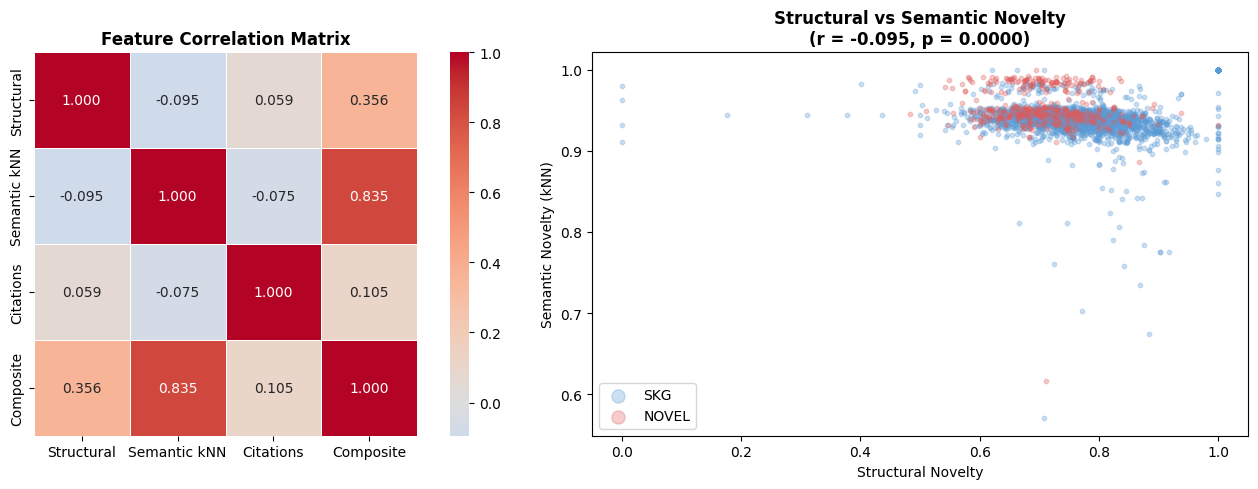

Saved: correlation_analysis.png


In [21]:
# 4. Structural vs Semantic correlation 
df_corr = df[df['triple_count'] > 0].copy()  # only papers with actual triples

r, p = stats.pearsonr(
    df_corr['structural_novelty'].fillna(0),
    df_corr['semantic_knn'].fillna(0)
)
print(f"Pearson r (structural vs semantic): {r:.4f}  p = {p:.6f}")
print(f"n = {len(df_corr)} papers with triple_count > 0")
print()
if abs(r) < 0.3:
    print("Low correlation → components measure DIFFERENT things. Good for composite.")
elif abs(r) < 0.6:
    print("Moderate correlation → partial overlap between components.")
else:
    print("High correlation → components may be redundant.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
corr_cols   = ['structural_novelty', 'semantic_knn', 'cited_by_count', 'composite_novelty']
corr_labels = ['Structural', 'Semantic kNN', 'Citations', 'Composite']
corr_matrix = df_corr[corr_cols].corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, ax=axes[0], linewidths=0.5, square=True)
axes[0].set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

# Scatter: structural vs semantic, coloured by split
for split, color in [('SKG','#5B9BD5'), ('NOVEL','#E05C5C')]:
    subset = df_corr[df_corr['split'] == split]
    axes[1].scatter(subset['structural_novelty'], subset['semantic_knn'],
                    alpha=0.3, s=10, color=color, label=split)
axes[1].set_xlabel('Structural Novelty')
axes[1].set_ylabel('Semantic Novelty (kNN)')
axes[1].set_title(f'Structural vs Semantic Novelty\n(r = {r:.3f}, p = {p:.4f})',
                  fontsize=12, fontweight='bold')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.savefig("../../outputs/visuals/" + 'correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: correlation_analysis.png")

In [22]:
# 5. Summary statistics table
summary = (
    df[df['split'].isin(['NOVEL','SKG'])]
    .groupby(['domain', 'split'])
    .agg(
        count           = ('paper_id', 'count'),
        composite_mean  = ('composite_novelty', 'mean'),
        composite_std   = ('composite_novelty', 'std'),
        structural_mean = ('structural_novelty', 'mean'),
        semantic_mean   = ('semantic_knn', 'mean'),
        triple_mean     = ('triple_count', 'mean'),
    )
    .round(4)
    .reset_index()
)

summary.to_csv(OUT_DIR + 'summary_statistics.csv', index=False)
print("Saved: summary_statistics.csv")
print()
print(summary.to_string(index=False))

Saved: summary_statistics.csv

domain split  count  composite_mean  composite_std  structural_mean  semantic_mean  triple_mean
   DIA NOVEL     56          0.7880         0.0356           0.7249         0.9476     116.1786
   DIA   SKG    217          0.7869         0.0427           0.7697         0.9352     115.4378
    MT NOVEL    172          0.7854         0.0607           0.6960         0.9523     129.8314
    MT   SKG    951          0.7900         0.0518           0.7684         0.9407     106.1441
   NLI   SKG     12          0.7820         0.0259           0.7194         0.9398     139.7500
   PAR   SKG    127          0.7846         0.0533           0.7865         0.9349     102.7480
    QA NOVEL     68          0.8007         0.0387           0.7128         0.9562     125.9118
    QA   SKG    307          0.7882         0.0381           0.7589         0.9375     114.0814
    SA NOVEL     61          0.8070         0.0463           0.7215         0.9559     133.5410
    SA   

In [25]:
# 6. Overall summary 
print(" OVERALL SCORE SUMMARY ")
overall = (
    df[df['split'].isin(['NOVEL','SKG'])]
    .groupby('split')[['structural_novelty','semantic_knn','composite_novelty']]
    .mean()
    .round(4)
)
print(overall)
print()
print(" Files saved ")
print("- top20_novel_papers.csv")
print("- bottom20_incremental_papers.csv")
print("- novelty_over_time.png")
print("- novelty_by_domain.png")
print("- correlation_analysis.png")
print("- summary_statistics.csv")

 OVERALL SCORE SUMMARY 
       structural_novelty  semantic_knn  composite_novelty
split                                                     
NOVEL              0.7088        0.9536             0.7946
SKG                0.7691        0.9382             0.7892

 Files saved 
- top20_novel_papers.csv
- bottom20_incremental_papers.csv
- novelty_over_time.png
- novelty_by_domain.png
- correlation_analysis.png
- summary_statistics.csv
